# Climate Change - AQI Prediction Using ARIMA and LSTM

* Air quality degradation is one of the major climate challenges, directly impacting public health and environmental sustainability.

* This project focuses on forecasting Air Quality Index (AQI) using ARIMA and LSTM models.

* The objectives include conducting exploratory data analysis, identifying trends, building predictive models, and evaluating their performance.

* While climate change involves multiple dimensions such as temperature rise and extreme weather, this project narrows the scope to AQI forecasting,
providing actionable insights into long-term air quality trends.

* The model comparison (ARIMA vs Univariate LSTM vs Multivariate LSTM) and extends to short-term forecasting for 20 days.







## Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

## Load the dataset

In [ ]:
df = pd.read_csv('/content/New Delhi AQI.csv')
df

,City,Date,PM2.5,PM10,NO2,SO2,CO,Ozone,AQI
0,New Delhi,01-01-2021,180.57,458.90,42.35,10.03,1.57,19.04,336.0
1,New Delhi,02-01-2021,146.71,371.52,27.41,10.05,1.14,13.37,351.0
2,New Delhi,03-01-2021,76.94,190.39,13.17,10.32,0.96,14.67,241.0
3,New Delhi,04-01-2021,58.12,111.38,67.60,12.79,1.01,12.77,90.0
4,New Delhi,05-01-2021,44.66,86.96,55.96,9.97,1.41,15.82,99.0
...,...,...,...,...,...,...,...,...,...
1456,New Delhi,27-12-2024,88.87,207.80,46.84,12.82,1.16,14.42,271.0
1457,New Delhi,28-12-2024,55.08,117.37,45.07,12.65,0.87,14.12,192.5
1458,New Delhi,29-12-2024,53.17,118.80,40.12,12.39,0.93,14.47,114.0
1459,New Delhi,30-12-2024,49.95,123.37,41.16,12.67,0.99,15.26,112.0


In [ ]:
df.shape

(1461, 9)

In [ ]:
df.head()

,City,Date,PM2.5,PM10,NO2,SO2,CO,Ozone,AQI
0,New Delhi,01-01-2021,180.57,458.90,42.35,10.03,1.57,19.04,336.0
1,New Delhi,02-01-2021,146.71,371.52,27.41,10.05,1.14,13.37,351.0
2,New Delhi,03-01-2021,76.94,190.39,13.17,10.32,0.96,14.67,241.0
3,New Delhi,04-01-2021,58.12,111.38,67.60,12.79,1.01,12.77,90.0
4,New Delhi,05-01-2021,44.66,86.96,55.96,9.97,1.41,15.82,99.0


In [ ]:
df.tail()

,City,Date,PM2.5,PM10,NO2,SO2,CO,Ozone,AQI
1456,New Delhi,27-12-2024,88.87,207.80,46.84,12.82,1.16,14.42,271.0
1457,New Delhi,28-12-2024,55.08,117.37,45.07,12.65,0.87,14.12,192.5
1458,New Delhi,29-12-2024,53.17,118.80,40.12,12.39,0.93,14.47,114.0
1459,New Delhi,30-12-2024,49.95,123.37,41.16,12.67,0.99,15.26,112.0
1460,New Delhi,31-12-2024,62.86,156.64,45.58,12.22,1.04,15.61,136.0


## Dataset Overview

In [ ]:
df.columns

Index(['City', 'Date', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone', 'AQI'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   City    1461 non-null   object 
 1   Date    1461 non-null   object 
 2   PM2.5   1461 non-null   float64
 3   PM10    1461 non-null   float64
 4   NO2     1461 non-null   float64
 5   SO2     1461 non-null   float64
 6   CO      1461 non-null   float64
 7   Ozone   1461 non-null   float64
 8   AQI     1461 non-null   float64
dtypes: float64(7), object(2)
memory usage: 102.9+ KB


In [ ]:
df.describe()

,PM2.5,PM10,NO2,SO2,CO,Ozone,AQI
count,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000,1461.000000
mean,108.501773,225.935578,30.483183,10.723361,1.078809,27.476728,222.060575
std,68.228667,118.388967,14.259208,4.158789,0.412606,12.782420,105.834787
min,8.330000,25.410000,4.760000,2.810000,0.230000,3.260000,35.000000
25%,55.450000,129.030000,19.890000,7.650000,0.810000,17.570000,130.000000
50%,93.440000,223.090000,28.420000,10.000000,0.980000,24.440000,223.000000
75%,147.670000,302.720000,39.100000,12.750000,1.230000,35.590000,307.000000
max,455.130000,819.240000,101.780000,47.050000,4.390000,88.860000,498.000000


In [ ]:
df.count()

,0
City,1461
Date,1461
PM2.5,1461
PM10,1461
NO2,1461
SO2,1461
CO,1461
Ozone,1461
AQI,1461


In [ ]:
df.value_counts()

City       Date        PM2.5   PM10    NO2    SO2    CO    Ozone  AQI  
New Delhi  31-12-2024  62.86   156.64  45.58  12.22  1.04  15.61  136.0    1
           01-01-2021  180.57  458.90  42.35  10.03  1.57  19.04  336.0    1
           01-01-2022  253.50  379.13  36.71  11.85  1.61  22.19  319.0    1
           01-01-2023  133.15  261.10  26.96  6.65   1.31  17.20  257.0    1
           01-01-2024  182.82  260.78  33.10  6.79   1.59  25.41  358.0    1
                                                                          ..
           01-03-2022  140.87  238.47  41.65  9.34   0.74  22.69  373.0    1
           01-03-2021  65.20   224.29  31.05  10.37  1.04  25.26  186.0    1
           01-02-2024  66.93   95.80   20.05  10.17  1.24  23.93  178.0    1
           01-02-2023  102.90  229.47  24.75  11.37  0.60  36.80  230.0    1
           01-02-2022  138.09  214.65  39.09  10.39  1.43  15.30  312.0    1
Name: count, Length: 1461, dtype: int64

## Data Preprocessing

In [ ]:
# Checking null or missing values
df.isnull().sum()

,0
City,0
Date,0
PM2.5,0
PM10,0
NO2,0
SO2,0
CO,0
Ozone,0
AQI,0


In [ ]:
# Convert Date into Datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.set_index('Date', inplace=True)

In [ ]:
# Checking if the data is sorted
df = df.sort_index()
df

,City,Date,PM2.5,PM10,NO2,SO2,CO,Ozone,AQI
0,New Delhi,2021-01-01,180.57,458.90,42.35,10.03,1.57,19.04,336.0
1,New Delhi,2021-01-02,146.71,371.52,27.41,10.05,1.14,13.37,351.0
2,New Delhi,2021-01-03,76.94,190.39,13.17,10.32,0.96,14.67,241.0
3,New Delhi,2021-01-04,58.12,111.38,67.60,12.79,1.01,12.77,90.0
4,New Delhi,2021-01-05,44.66,86.96,55.96,9.97,1.41,15.82,99.0
...,...,...,...,...,...,...,...,...,...
1456,New Delhi,2024-12-27,88.87,207.80,46.84,12.82,1.16,14.42,271.0
1457,New Delhi,2024-12-28,55.08,117.37,45.07,12.65,0.87,14.12,192.5
1458,New Delhi,2024-12-29,53.17,118.80,40.12,12.39,0.93,14.47,114.0
1459,New Delhi,2024-12-30,49.95,123.37,41.16,12.67,0.99,15.26,112.0


## Exploratory Data Analysis (EDA)

<Axes: >

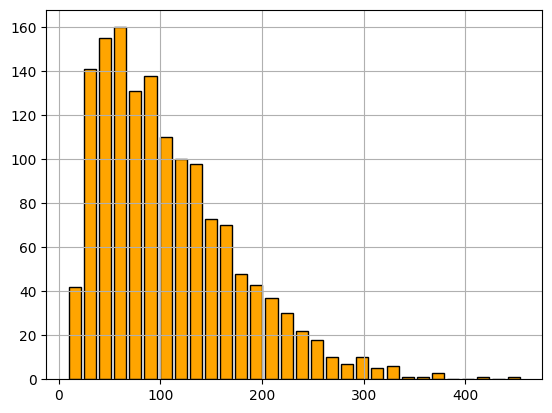

In [ ]:
#histogram
df['PM2.5'].hist(bins=30, rwidth=0.8, color='orange', edgecolor='black')

<Axes: >

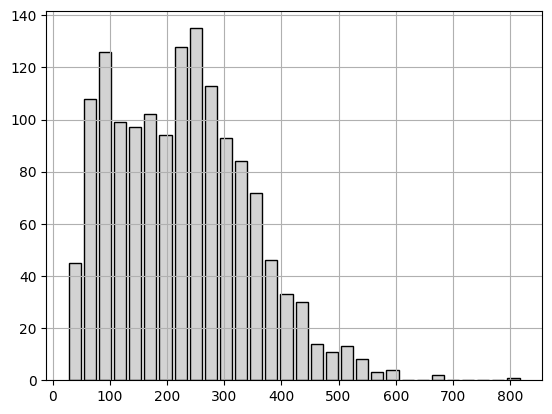

In [ ]:
df['PM10'].hist(bins=30, rwidth=0.8, color='Lightgrey', edgecolor='black')

<Axes: >

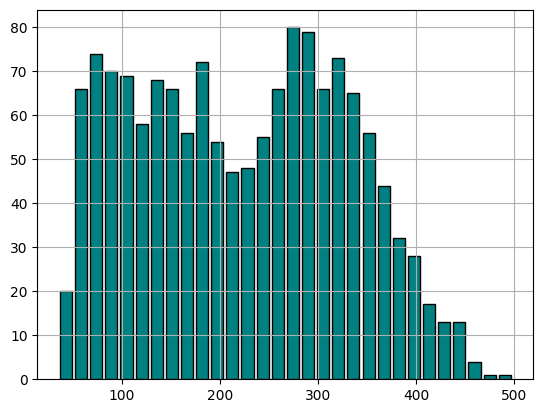

In [ ]:
df['AQI'].hist(bins=30, rwidth=0.8, color='teal', edgecolor='black')

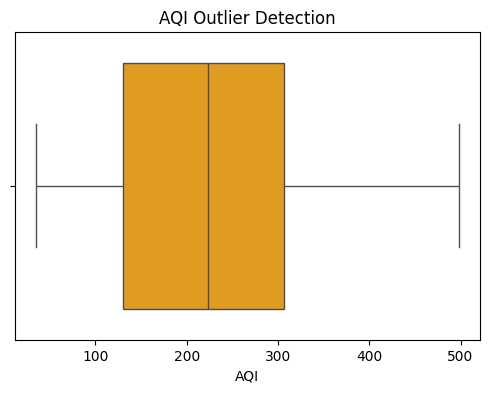

In [ ]:
# Box Plot
plt.figure(figsize=(6,4))
sns.boxplot(x=df['AQI'], color ='orange')
plt.title("AQI Outlier Detection")
plt.show()

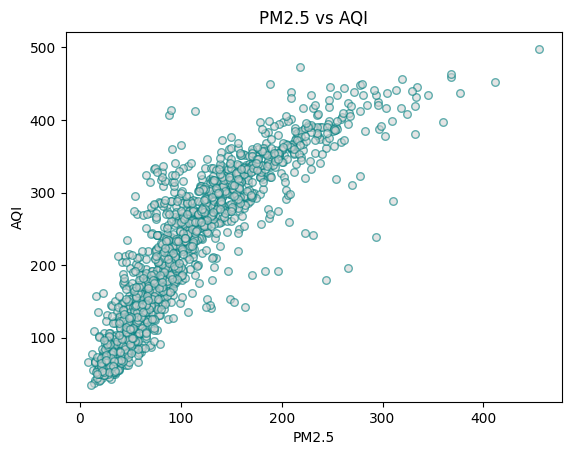

In [ ]:
# Scatter Plot
plt.scatter(df['PM2.5'], df['AQI'], color = 'lightgrey', edgecolor='teal', s=30, alpha=0.6)
plt.xlabel("PM2.5")
plt.ylabel("AQI")
plt.title("PM2.5 vs AQI")
plt.show()

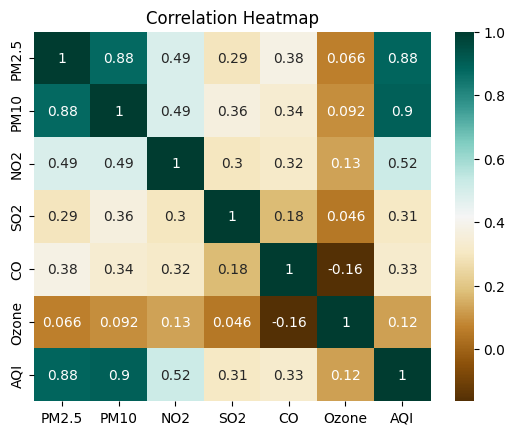

In [ ]:
# Correlation Heatmap
numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='BrBG')
plt.title("Correlation Heatmap")
plt.show()

## Time Series Preparation

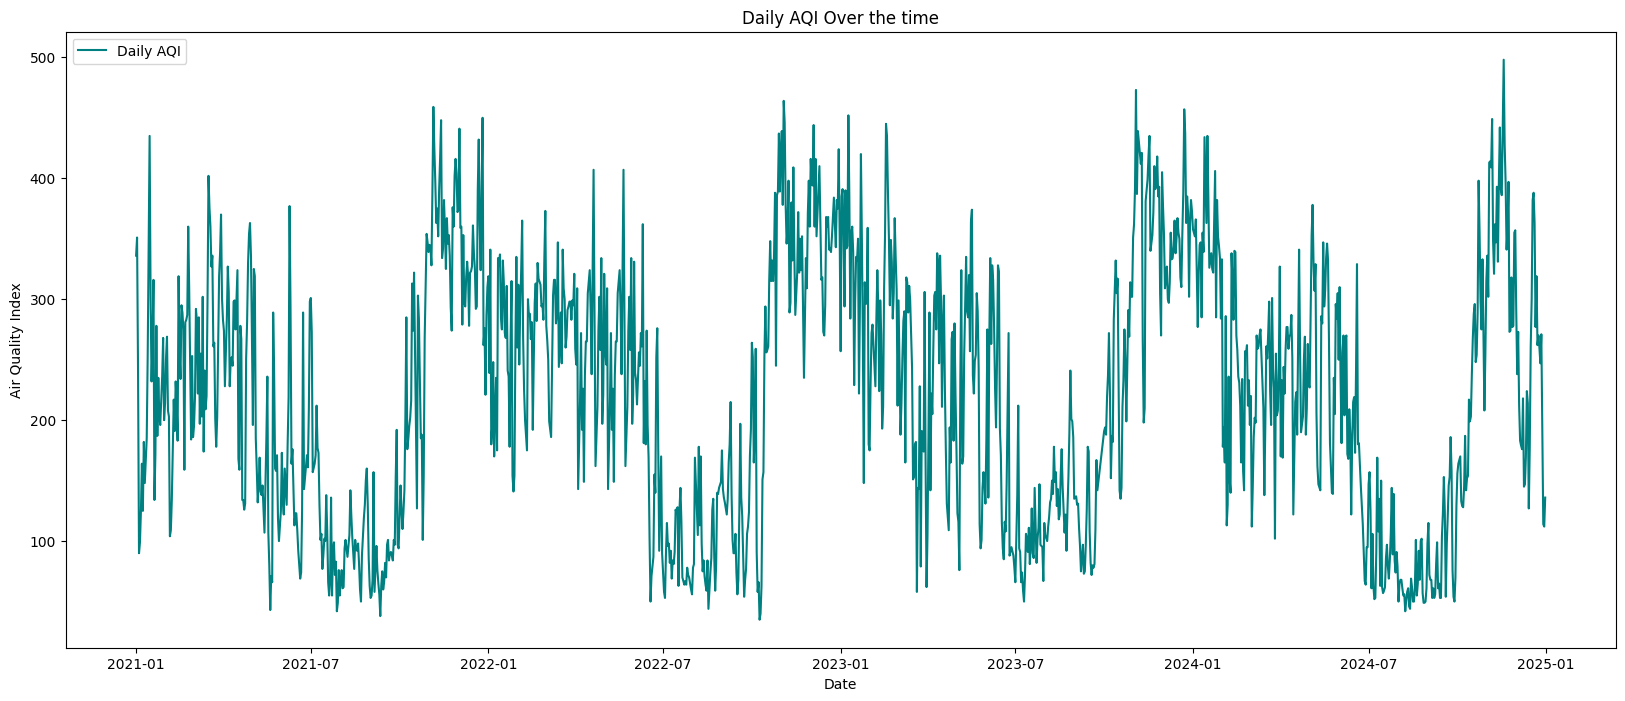

In [ ]:
# Visulaize the time series
plt.figure(figsize=(20,8))
plt.plot(df['AQI'], label = "Daily AQI", color ='teal')
plt.title("Daily AQI Over the time")
plt.xlabel("Date")
plt.ylabel("Air Quality Index")
plt.legend()
plt.show()

In [ ]:
# Feature Selection
city = df['City'].iloc[0]
city_data = df[df['City'] == city]

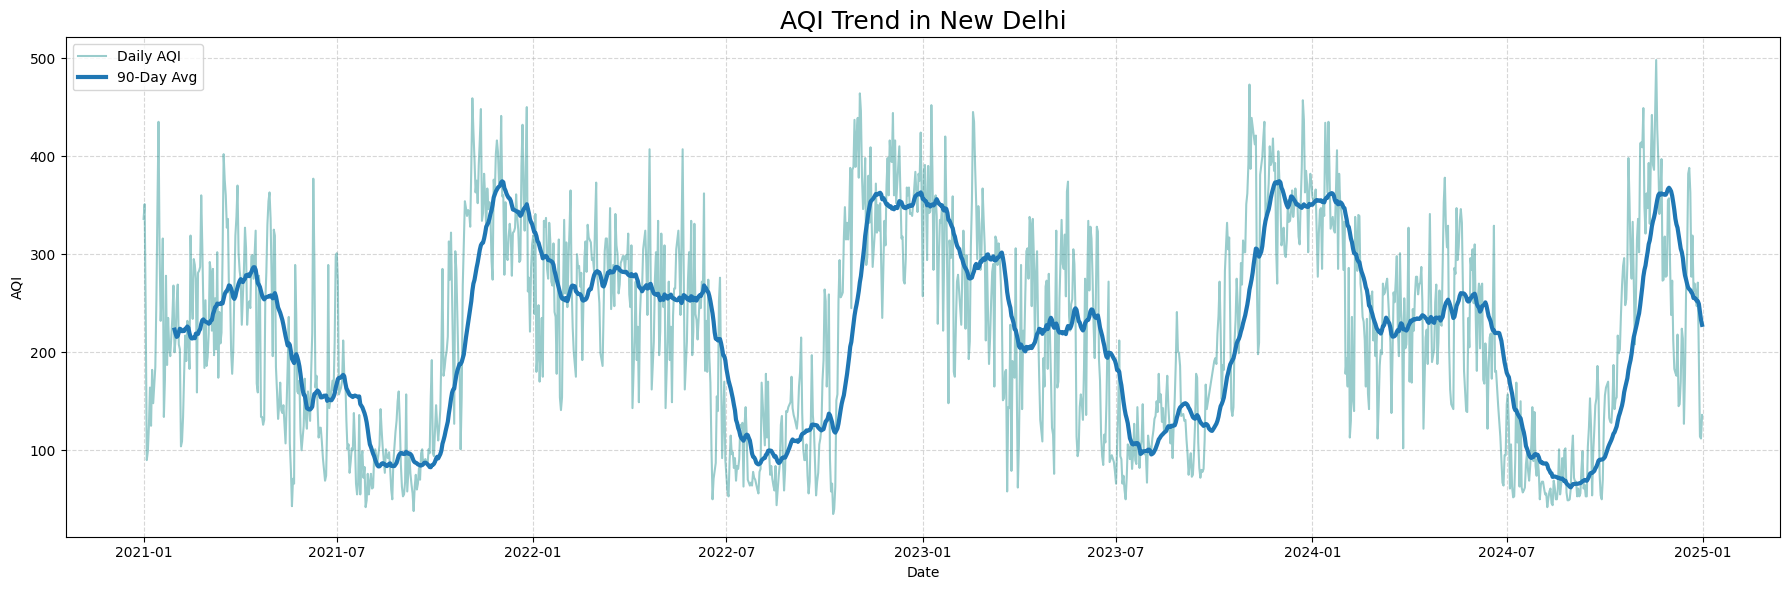

In [ ]:
# Visualization the AQI with the time series
rolling = city_data['AQI'].rolling(30).mean()

plt.figure(figsize=(18,6))
plt.plot(city_data.index, city_data['AQI'], alpha=0.4, label="Daily AQI", color = 'teal')
plt.plot(city_data.index, rolling, linewidth=3, label="30-Day Avg")

plt.title(f"AQI Trend in {city}", fontsize=18)
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

In [ ]:
# Checking missing values
print(city_data.isnull().sum())
city_data['AQI'].fillna(method='ffill', inplace=True)

City     0
PM2.5    0
PM10     0
NO2      0
SO2      0
CO       0
Ozone    0
AQI      0
dtype: int64


/tmp/ipykernel_1495/3484745591.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  city_data['AQI'].fillna(method='ffill', inplace=True)
/tmp/ipykernel_1495/3484745591.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  city_data['AQI'].fillna(method='ffill', inplace=True)


In [ ]:
# Checking duplicates
df.index.duplicated().sum()

np.int64(0)

In [ ]:
# Describing AQI
df['AQI'].describe()

,AQI
count,1461.000000
mean,222.060575
std,105.834787
min,35.000000
25%,130.000000
50%,223.000000
75%,307.000000
max,498.000000


## ARIMA Model
We have to check 3 parameters p, d, q befor fitting ARIMA.


In [ ]:
# Checking Stationary d value
from statsmodels.tsa.stattools import adfuller
adfuller(df['AQI'])

(np.float64(-3.422327558636139),
 np.float64(0.010220871018065411),
 14,
 1446,
 {'1%': np.float64(-3.434880391815318),
  '5%': np.float64(-2.8635408625359315),
  '10%': np.float64(-2.5678352438452814)},
 np.float64(15309.3728180201))

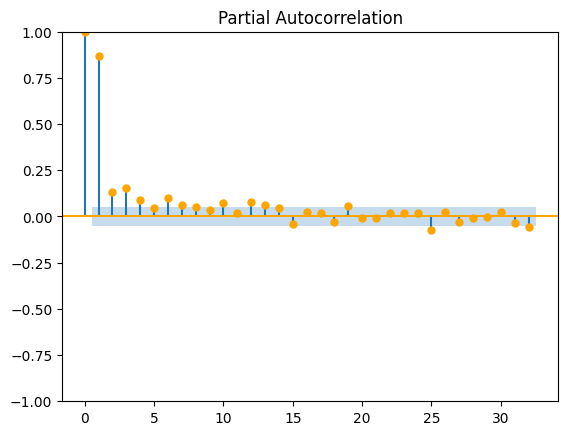

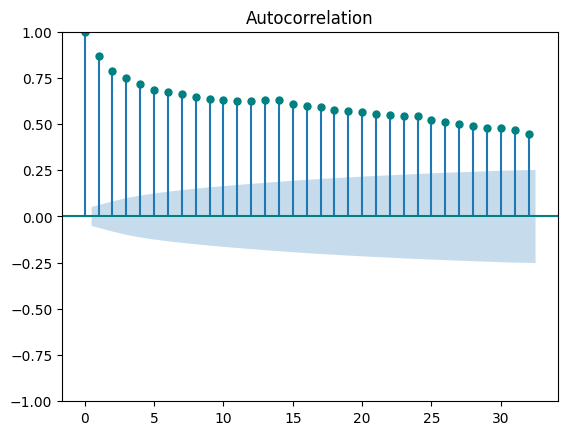

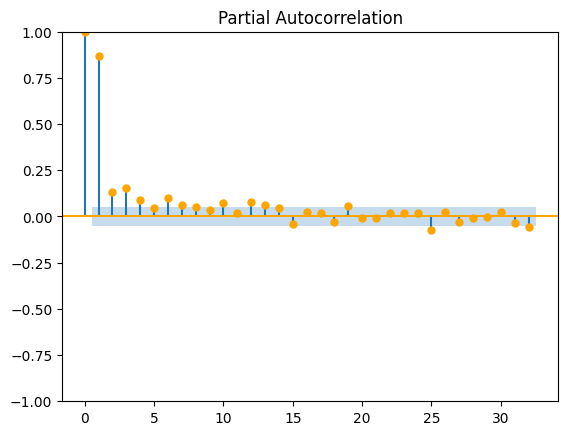

In [ ]:
# Checking p value and q value (ACF, PACF Plots)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df['AQI'], color = 'teal')
plot_pacf(df['AQI'], color = 'orange')

In [ ]:
# Train Test Split
train = city_data.loc['01-01-2021':'31-12-2023']
test  = city_data.loc['01-01-2024':'31-12-2024']

In [ ]:
# Build and fit an ARIMA model
model = ARIMA(df['AQI'], order=(2,1,2))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                    AQI   No. Observations:                 1461
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -7794.460
Date:                Fri, 27 Mar 2026   AIC                          15598.920
Time:                        17:03:16   BIC                          15625.351
Sample:                             0   HQIC                         15608.780
                               - 1461                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3663      0.202     -1.817      0.069      -0.762       0.029
ar.L2          0.5377      0.108      4.959      0.000       0.325       0.750
ma.L1          0.0502      0.204      0.245      0.8

In [ ]:
# Forecasting Test Period
forecast = model_fit.forecast(steps=len(test))

In [ ]:
# Evaluation model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

actual = test['AQI'].values
predicted = forecast.values

mae_arima = mean_absolute_error(actual, predicted)
mse_arima = mean_squared_error(actual, predicted)
rmse_arima = np.sqrt(mse_arima)
r2_arima = r2_score(actual, predicted)

print("MAE:", mae_arima)
print("MSE:", mse_arima)
print("RMSE:", rmse_arima)
print("R2:", r2_arima)

MAE: 106.56420765027322
MSE: 17037.699377652396
RMSE: 130.5285385563341
R2: -0.518639757097795


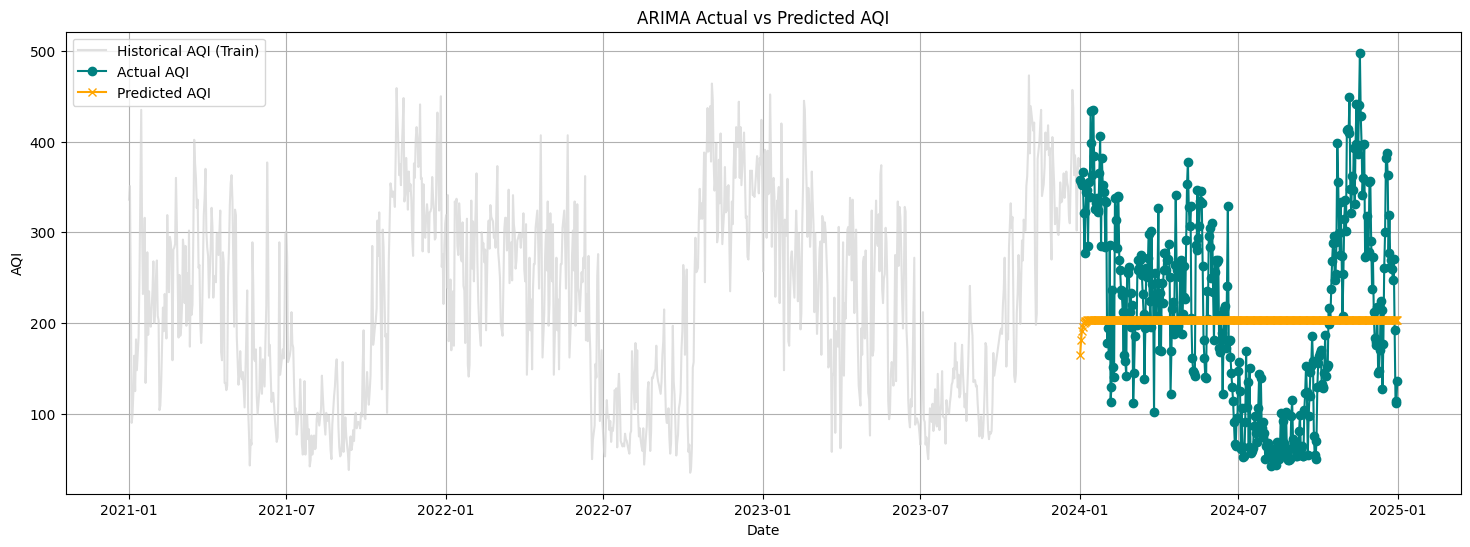

In [ ]:
# Actual vs Predicted Visualization
plt.figure(figsize=(18,6))

plt.plot(train.index, train['AQI'], label="Historical AQI (Train)", color='lightgray', alpha=0.7)

plt.plot(test.index, actual, label="Actual AQI", marker='o', color = 'teal')
plt.plot(test.index, forecast, label="Predicted AQI", marker='x', color='orange')
plt.title("ARIMA Actual vs Predicted AQI")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Predict 30 days beyond the end of your dataset
future_forecast = model_fit.forecast(steps=len(test) + 30)

print(future_forecast.tail(30))

2026-01-02    203.624265
2026-01-03    203.624265
2026-01-04    203.624265
2026-01-05    203.624265
2026-01-06    203.624265
2026-01-07    203.624265
2026-01-08    203.624265
2026-01-09    203.624265
2026-01-10    203.624265
2026-01-11    203.624265
2026-01-12    203.624265
2026-01-13    203.624265
2026-01-14    203.624265
2026-01-15    203.624265
2026-01-16    203.624265
2026-01-17    203.624265
2026-01-18    203.624265
2026-01-19    203.624265
2026-01-20    203.624265
2026-01-21    203.624265
2026-01-22    203.624265
2026-01-23    203.624265
2026-01-24    203.624265
2026-01-25    203.624265
2026-01-26    203.624265
2026-01-27    203.624265
2026-01-28    203.624265
2026-01-29    203.624265
2026-01-30    203.624265
2026-01-31    203.624265
Freq: D, Name: predicted_mean, dtype: float64


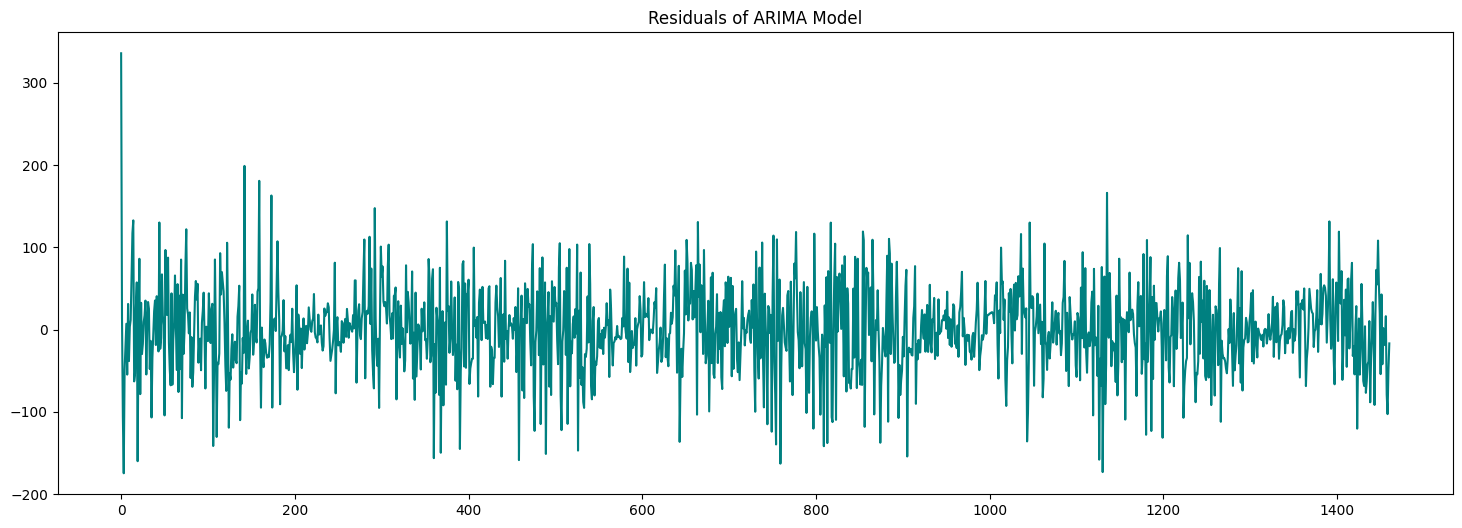

In [ ]:
# Residual Analysis (It shows how the specific model is performing on a dataset)
residuals = model_fit.resid

plt.figure(figsize=(18,6))
plt.plot(residuals, color='teal')
plt.title("Residuals of ARIMA Model")
plt.show()

## LSTM Model

### Univariate LSTM Model

In [ ]:
# Data Preparation using Univariant
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Use AQI column as target
values = df['AQI'].values.reshape(-1,1)

# Scale values between 0 and 1
scaler_uni = MinMaxScaler(feature_range=(0,1))
scaled_uni = scaler_uni.fit_transform(values)

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data)-seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 30
X_uni, y_uni = create_sequences(scaled_uni, seq_length)

X_uni = X_uni.reshape((X_uni.shape[0], X_uni.shape[1], 1))

# Train-test split
split_uni = int(0.8 * len(X_uni))
X_train_uni, X_test_uni = X_uni[:split_uni], X_uni[split_uni:]
y_train_uni, y_test_uni = y_uni[:split_uni], y_uni[split_uni:]

In [ ]:
pip install tensorflow numpy pandas scikit-learn matplotlib

In [ ]:
# Build the LSTM Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model_uni = Sequential()
model_uni.add(LSTM(64, input_shape=(seq_length, 1)))
model_uni.add(Dense(1))
model_uni.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Train the model
history_uni = model_uni.fit(X_train_uni, y_train_uni,
                            epochs=20, batch_size=32,
                            validation_data=(X_test_uni, y_test_uni),
                            verbose=1)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 0.0670 - val_loss: 0.0207
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0206 - val_loss: 0.0193
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0195 - val_loss: 0.0187
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0189 - val_loss: 0.0178
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0184 - val_loss: 0.0172
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0177 - val_loss: 0.0168
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0175 - val_loss: 0.0158
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0169 - val_loss: 0.0155
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0165 - val_loss: 0.0149
Epoch 10/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0160 - val_loss: 0.0151
Epoch 11/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0161 - val_loss: 0.0140
Epoch 12/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0

In [ ]:
# Predict on test set
y_pred_uni = model_uni.predict(X_test_uni)

# Inverse transform back to original scale
y_test_uni_inv = scaler_uni.inverse_transform(y_test_uni.reshape(-1,1))
y_pred_uni_inv = scaler_uni.inverse_transform(y_pred_uni)

# Metrics
rmse_uni = np.sqrt(mean_squared_error(y_test_uni_inv, y_pred_uni_inv))
mae_uni = mean_absolute_error(y_test_uni_inv, y_pred_uni_inv)

print("Univariate LSTM RMSE:", rmse_uni)
print("Univariate LSTM MAE:", mae_uni)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Univariate LSTM RMSE: 49.52379096376313
Univariate LSTM MAE: 40.09230107962047


### Multivariate LSTM Model

In [ ]:
# Data Preparation using Multivariant
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

df = pd.read_csv('/content/New Delhi AQI.csv')
df

df['AQI_lag1']   = df['AQI'].shift(1)    # yesterday
df['AQI_lag7']   = df['AQI'].shift(7)    # one week ago
df['AQI_lag30']  = df['AQI'].shift(30)   # one month ago
df['AQI_lag90']  = df['AQI'].shift(90)   # one season ago

# Rolling averages for short + long term
df['AQI_roll7']   = df['AQI'].rolling(window=7).mean()     # weekly
df['AQI_roll30']  = df['AQI'].rolling(window=30).mean()    # monthly
df['AQI_roll90']  = df['AQI'].rolling(window=90).mean()    # quarterly
df['AQI_roll180'] = df['AQI'].rolling(window=180).mean()   # half‑year

df['PM25_lag1']   = df['PM2.5'].shift(1)
df['PM25_roll7']  = df['PM2.5'].rolling(window=7).mean()
df['PM25_roll30'] = df['PM2.5'].rolling(window=30).mean()

# Strip spaces from column names
df.columns = df.columns.str.strip()

# Save timeline
dates = df['Date']

# Drop non-numeric columns
df_numeric = df.drop(columns=['City','Date'])

# Drop NaNs and align dates
df_numeric = df_numeric.dropna().reset_index(drop=True)
dates = dates.loc[df_numeric.index]

# Scale numeric features
scaler_multi = MinMaxScaler(feature_range=(0,1))
scaled_multi = scaler_multi.fit_transform(df_numeric.values)

def create_sequences(data, seq_length, target_idx):
    X, y = [], []
    for i in range(len(data)-seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length, target_idx])  # AQI target
    return np.array(X), np.array(y)

target_idx = df_numeric.columns.get_loc('AQI')
seq_length = 90
X, y = create_sequences(scaled_multi, seq_length, target_idx)

# Train-test split
split = int(0.75 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
pip install tensorflow numpy pandas scikit-learn matplotlib

In [ ]:
# Build the LSTM Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = keras.Sequential()
model.add(keras.layers.LSTM(100, input_shape=(
    X_train.shape[1], X_train.shape[2])))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(1))

model.compile(loss="mse", optimizer="adam", metrics=["mae"])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 100)            │        47,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,701 (186.33 KB)

 Trainable params: 47,701 (186.33 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=5, min_delta=1e-3, restore_best_weights=True)

history = model.fit(X_train, y_train, epochs=50, batch_size=16)

Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 0.0112 - mae: 0.0815
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - loss: 0.0116 - mae: 0.0828
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 0.0113 - mae: 0.0820
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - loss: 0.0111 - mae: 0.0812
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0113 - mae: 0.0825
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0117 - mae: 0.0838
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0112 - mae: 0.0811
Epoch 8/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0112 - mae: 0.0816
Epoch 9/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 0.0110 - mae: 0.0810
Epoch 10/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0113 - mae: 0.0827
Epoch 11/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0112 - mae: 0.0822
Epoch 12/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0112 - mae: 0.0812
Epoch 13/50
56/56 ━━━━━━━━━━━━━━━━━━━

In [ ]:
# Predict on test set
y_pred = model.predict(X_test)

# Inverse transform only AQI
y_test_multi_inv = scaler_multi.inverse_transform(np.concatenate([y_test.reshape(-1,1),
                                                      np.zeros((len(y_test), X.shape[2]-1))], axis=1))[:,0]
y_pred_multi_inv = scaler_multi.inverse_transform(np.concatenate([y_pred,
                                                      np.zeros((len(y_pred), X.shape[2]-1))], axis=1))[:,0]

from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse_multi = np.sqrt(mean_squared_error(y_test_multi_inv, y_pred_multi_inv))
mae_multi = mean_absolute_error(y_test_multi_inv, y_pred_multi_inv)

print("Multivariate LSTM RMSE:", rmse_multi)
print("Multivariate LSTM MAE:", mae_multi)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
Multivariate LSTM RMSE: 42.495606251193955
Multivariate LSTM MAE: 33.230714189651884


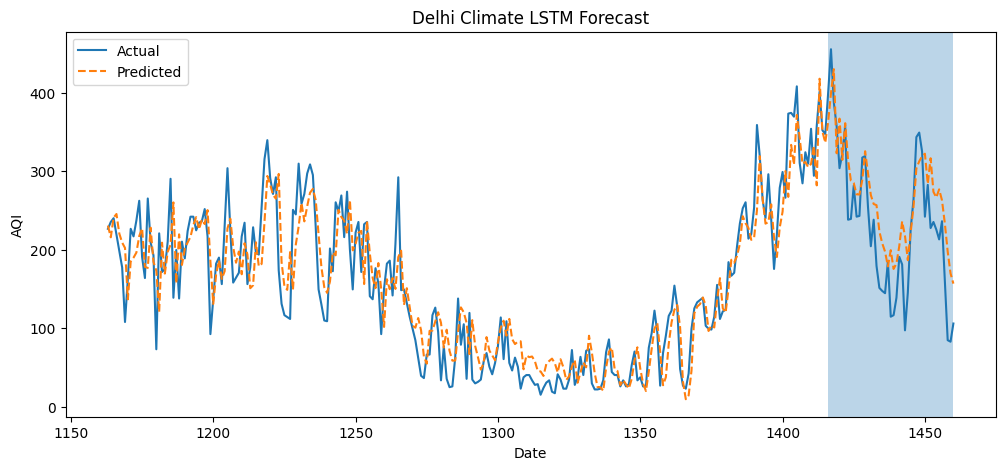

In [ ]:
# Actual vs Predicted Visual
date = df.index[-len(y_test):]

plt.figure(figsize=(12, 5))
plt.plot(date, y_test_multi_inv, label="Actual")
plt.plot(date, y_pred_multi_inv, linestyle="--", label="Predicted")

highlight = int(len(date) * 0.85)
plt.axvspan(date[highlight], date[-1], alpha=0.3)

plt.title("Delhi Climate LSTM Forecast")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()
plt.show()

## Comparison Section

In [ ]:
# Collect metrics from both models
results = {
    "Model": ["Univariant LSTM", "Multivariant LSTM"],
    "RMSE": [rmse_uni, rmse_multi],
    "MAE": [mae_uni, mae_multi]
}

df_results = pd.DataFrame(results)
print(df_results)

               Model       RMSE        MAE
0    Univariant LSTM  49.523791  40.092301
1  Multivariant LSTM  40.419956  32.185484


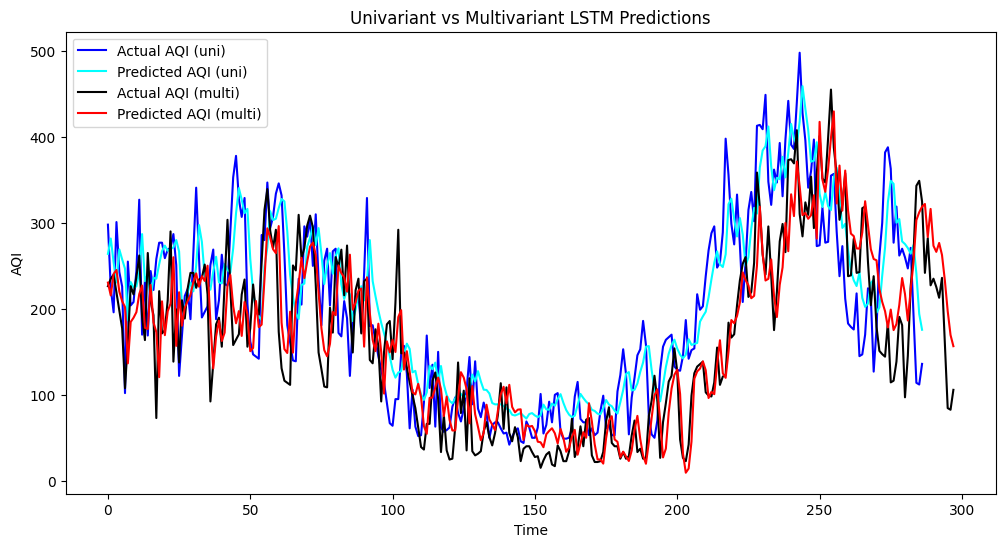

In [ ]:
# Comparision btw Univariate and Multivariate Visual
plt.figure(figsize=(12,6))

# Plot Univariate
plt.plot(y_test_uni_inv, label='Actual AQI (uni)', color='blue')
plt.plot(y_pred_uni_inv, label='Predicted AQI (uni)', color='cyan')

# Plot Multivariate
plt.plot(y_test_multi_inv, label='Actual AQI (multi)', color='black')
plt.plot(y_pred_multi_inv, label='Predicted AQI (multi)', color='red')

plt.title("Univariant vs Multivariant LSTM Predictions")
plt.xlabel("Time")
plt.ylabel("AQI")
plt.legend()
plt.show()

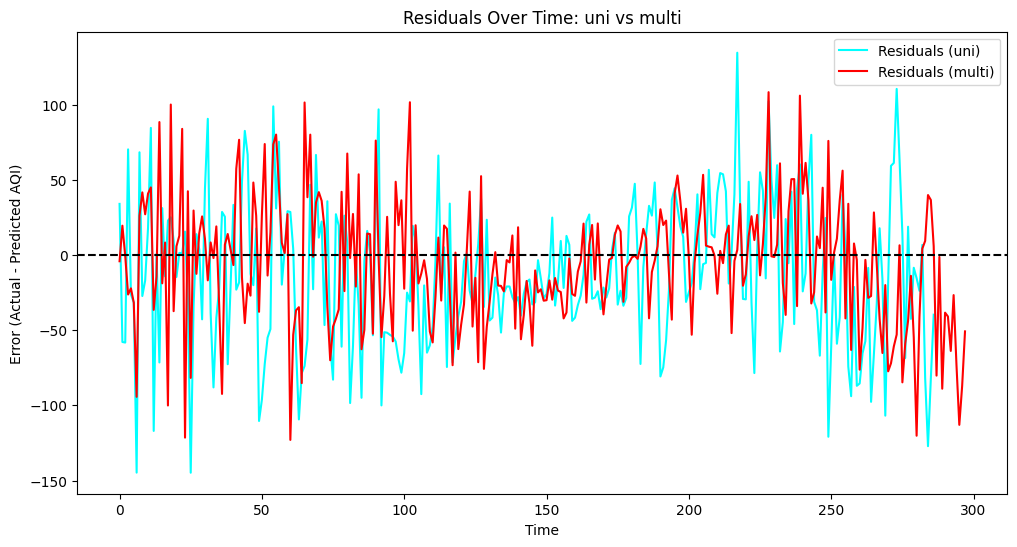

In [ ]:
# Residual Analysis
residuals_uni = y_test_uni_inv - y_pred_uni_inv
residuals_multi = y_test_multi_inv - y_pred_multi_inv

# Plot
plt.figure(figsize=(12,6))
plt.plot(residuals_uni, label='Residuals (uni)', color='cyan')
plt.plot(residuals_multi, label='Residuals (multi)', color='red')
plt.axhline(0, color='black', linestyle='--')
plt.title("Residuals Over Time: uni vs multi")
plt.xlabel("Time")
plt.ylabel("Error (Actual - Predicted AQI)")
plt.legend()
plt.show()

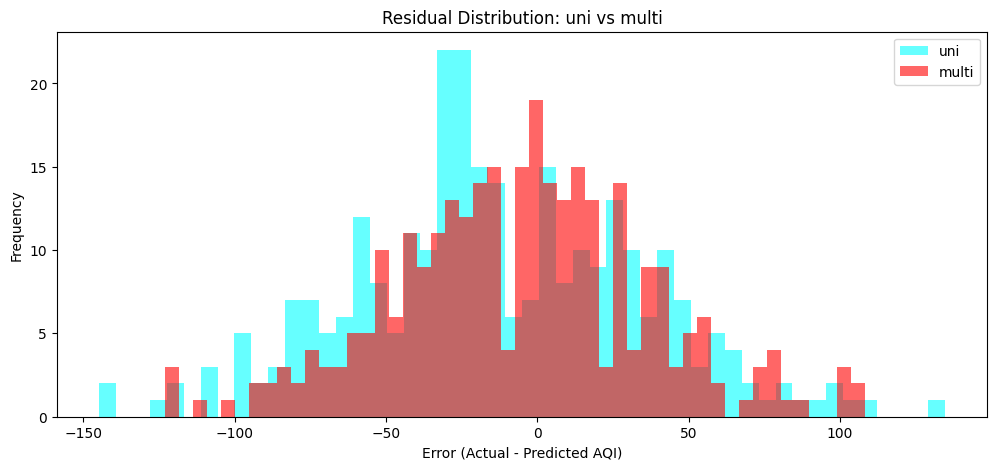

In [ ]:
# Histogram
plt.figure(figsize=(12,5))
plt.hist(residuals_uni, bins=50, alpha=0.6, label='uni', color='cyan')
plt.hist(residuals_multi, bins=50, alpha=0.6, label='multi', color='red')
plt.title("Residual Distribution: uni vs multi")
plt.xlabel("Error (Actual - Predicted AQI)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [ ]:
# Evaluation
eval_results = {
    "Model": ["uni", "multi"],
    "Mean Residual": [np.mean(residuals_uni), np.mean(residuals_multi)],
    "Std Dev Residual": [np.std(residuals_uni), np.std(residuals_multi)],
    "RMSE": [rmse_uni, rmse_multi],
    "MAE": [mae_uni, mae_multi]
}

df_eval = pd.DataFrame(eval_results)
print(df_eval)

   Model  Mean Residual  Std Dev Residual       RMSE        MAE
0    uni     -13.236195         47.722207  48.220000  38.820000
1  multi      -6.049879         42.062757  42.495606  33.230714


In [ ]:
# ARIMA, Univariate LSTM, Multivariate LSTM Model Evaluation Comparison
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results = {
    "Model": ["ARIMA", "Univariant LSTM", "Multivariant LSTM"],
    "RMSE": [rmse_arima, rmse_uni, rmse_multi],
    "MAE": [mae_arima, mae_uni, mae_multi]
}

df_results = pd.DataFrame(results)
print(df_results)

               Model        RMSE        MAE
0              ARIMA  106.644913  90.587599
1    Univariant LSTM   48.220000  38.820000
2  Multivariant LSTM   42.495606  33.230714


298 298 298 298


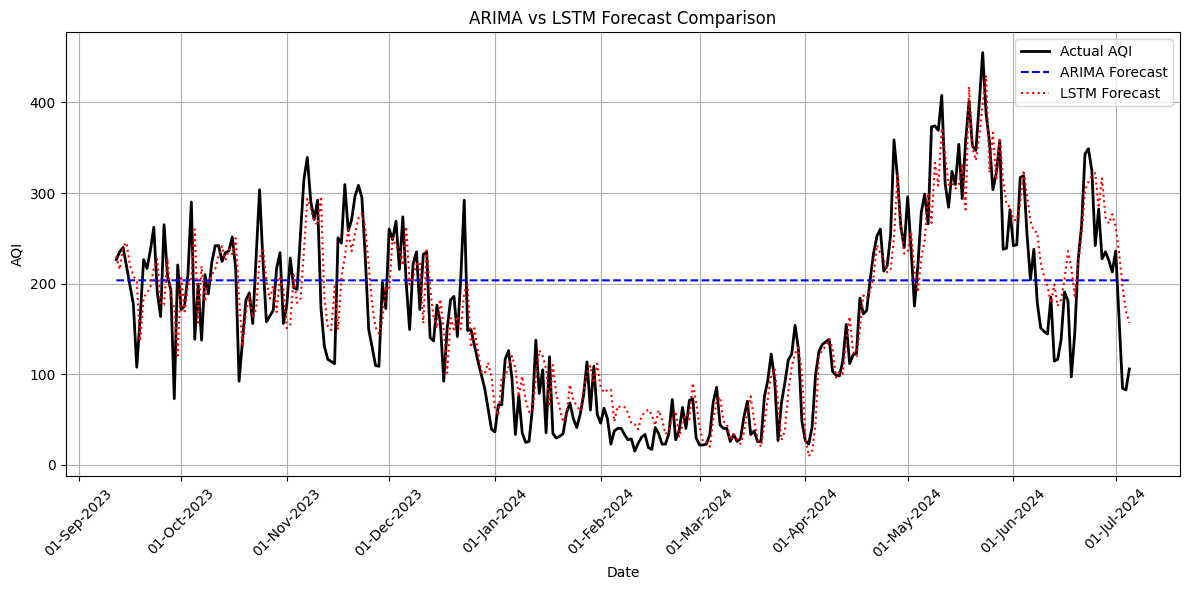

In [ ]:
# Actual AQI vs ARIMA vs LSTM Visualization

# Length of LSTM predictions
len_lstm = len(y_pred_multi_inv)

# Slice the last part of dates and actual values to match
test_dates = dates[-len_lstm:]
actual_values = y_test_multi_inv[-len_lstm:]
arima_values = forecast[-len_lstm:]
lstm_values = y_pred_multi_inv[-len_lstm:]

min_len = min(len(dates), len(y_test_multi_inv), len(forecast), len(y_pred_multi_inv))

df_compare = pd.DataFrame({
    'date': pd.to_datetime(dates[-min_len:].values, dayfirst=True),
    'actual': y_test_multi_inv[-min_len:],
    'arima_pred': forecast[-min_len:].values,
    'lstm_pred': y_pred_multi_inv[-min_len:]
}).reset_index(drop=True)

print(len(test_dates), len(actual_values), len(arima_values), len(lstm_values))

# Plot
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(12,6))

plt.plot(df_compare['date'], df_compare['actual'],
         label='Actual AQI', color='black', linewidth=2)

plt.plot(df_compare['date'], df_compare['arima_pred'],
         label='ARIMA Forecast', color='blue', linestyle='--')

plt.plot(df_compare['date'], df_compare['lstm_pred'],
         label='LSTM Forecast', color='red', linestyle=':')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%b-%Y'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.title('ARIMA vs LSTM Forecast Comparison')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# ARIMA & LSTM Prediction Values
display(df_compare.head())

,date,actual,arima_pred,lstm_pred
0,2023-09-12,226.422441,203.627767,230.543680
1,2023-09-13,235.107538,203.620977,215.580160
2,2023-09-14,239.932592,203.627352,240.645698
3,2023-09-15,219.024024,203.621366,245.269994
4,2023-09-16,198.115457,203.626987,220.265841


In [ ]:
display(df_compare.tail())

,date,actual,arima_pred,lstm_pred
293,2024-07-01,236.072549,203.624265,262.709670
294,2024-07-02,160.319201,203.624265,233.303647
295,2024-07-03,84.565853,203.624265,197.510759
296,2024-07-04,82.635832,203.624265,169.625333
297,2024-07-05,105.796091,203.624265,156.577567


## Future Forecasting

### Multi-Variate Future Prediction

In [ ]:
# Model_multi trained to predict n_output days ahead
n_input = seq_length
n_output = 20
df = pd.read_csv('/content/New Delhi AQI.csv')
df

# Ensure df['Date'] is datetime type
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Prepare the last input window (scaled) for multi-step prediction
current_input_sequence = scaled_multi[-n_input:].copy()

predicted_scaled_aqi_values = []

# Loop to predict n_output future steps
for _ in range(n_output):
    # Reshape for model input (1, seq_length, num_features)
    model_input = current_input_sequence.reshape(1, n_input, scaled_multi.shape[1])

    # Predict the next AQI value (scaled)
    predicted_aqi_scaled = model.predict(model_input, verbose=0)[0][0]
    predicted_scaled_aqi_values.append(predicted_aqi_scaled)

    # Create a new row to append to the sequence for the next prediction
    new_row = np.zeros(scaled_multi.shape[1])
    new_row[target_idx] = predicted_aqi_scaled

    # Update the current_input_sequence: remove the oldest step, add the new prediction
    current_input_sequence = np.vstack((current_input_sequence[1:], new_row))

# Inverse transform the predicted scaled AQI values
dummy_for_inverse = np.zeros((len(predicted_scaled_aqi_values), scaled_multi.shape[1]))
dummy_for_inverse[:, target_idx] = predicted_scaled_aqi_values
multi_pred_inv = scaler_multi.inverse_transform(dummy_for_inverse)[:, target_idx]

# Build future DataFrame
future_dates = pd.date_range(start=df['Date'].max() + pd.Timedelta(days=1),
                             periods=n_output, freq='D')

df_future_multi = pd.DataFrame({
    'date': future_dates,
    'lstm_multi_pred': multi_pred_inv.flatten()
})

display(df_future_multi)

,date,lstm_multi_pred
0,2025-01-01,203.421954
1,2025-01-02,141.019350
2,2025-01-03,106.289795
3,2025-01-04,82.859063
4,2025-01-05,68.170013
5,2025-01-06,60.181200
6,2025-01-07,56.991886
7,2025-01-08,56.831699
8,2025-01-09,58.226946
9,2025-01-10,60.116930


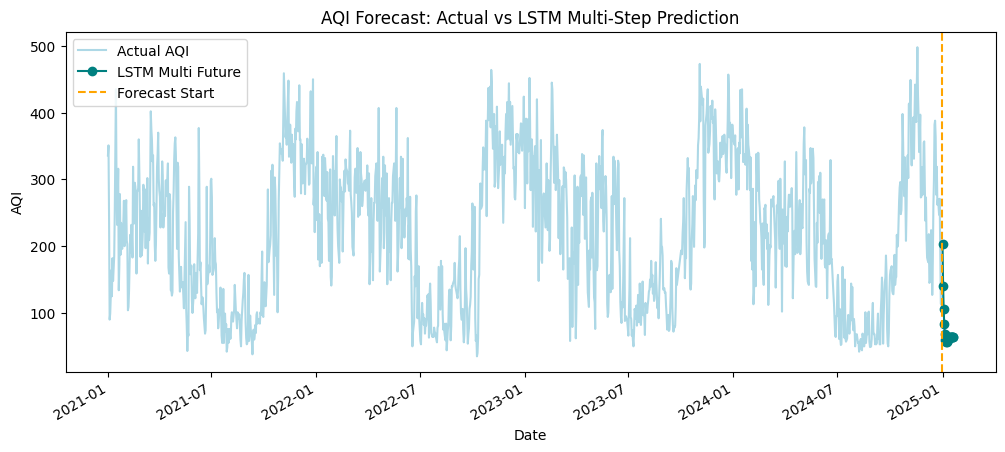

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Plot future LSTM multi predictions
plt.plot(df['Date'], df['AQI'], color='lightblue', label='Actual AQI')
plt.plot(df_future_multi['date'], df_future_multi['lstm_multi_pred'],
         color='teal', linestyle='-', marker='o', label='LSTM Multi Future')
# Mark forecast start
plt.axvline(x=df['Date'].max(), color='orange', linestyle='--', label='Forecast Start')
plt.xlabel("Date")
plt.ylabel("AQI")
plt.title("AQI Forecast: Actual vs LSTM Multi-Step Prediction")
plt.legend()
plt.gcf().autofmt_xdate()
plt.show()

### Univariate Future Prediction

In [ ]:
# Forecast Future Time Steps (Closed-Loop Forecasting)
def forecast_future(model, historical_data, n_future_steps, seq_len, scaler):
    forecast = []
    current_sequence = historical_data[-seq_len:].tolist()

    for _ in range(n_future_steps):
        # Reshape the current sequence to 3D
        input_seq = np.array(current_sequence).reshape(1, seq_len, 1)
        # Predict the next value
        predicted_value_scaled = model.predict(input_seq, verbose=0)[0][0]
        # Append the prediction to the forecast list
        forecast.append(predicted_value_scaled)
        # Update the sequence by removing the first element and adding the prediction
        current_sequence.pop(0)
        current_sequence.append([predicted_value_scaled])

    # Inverse transform the scaled forecast to original values
    forecast = scaler.inverse_transform(np.array(forecast).reshape(-1, 1))
    return forecast

# Make predictions for the next 100 time steps using the univariate LSTM model
n_future_steps = 100
# Using the univariate model's components
future_predictions_uni = forecast_future(model_uni, scaled_uni, n_future_steps, seq_length, scaler_uni)

# Plot the results
print(f"Predicted future values (first 10): {future_predictions_uni[:10].flatten()}")

Predicted future values (first 10): [181.85768 202.16873 218.44675 231.8603  242.40685 250.38683 256.31076
 260.73737 264.17532 267.03473]


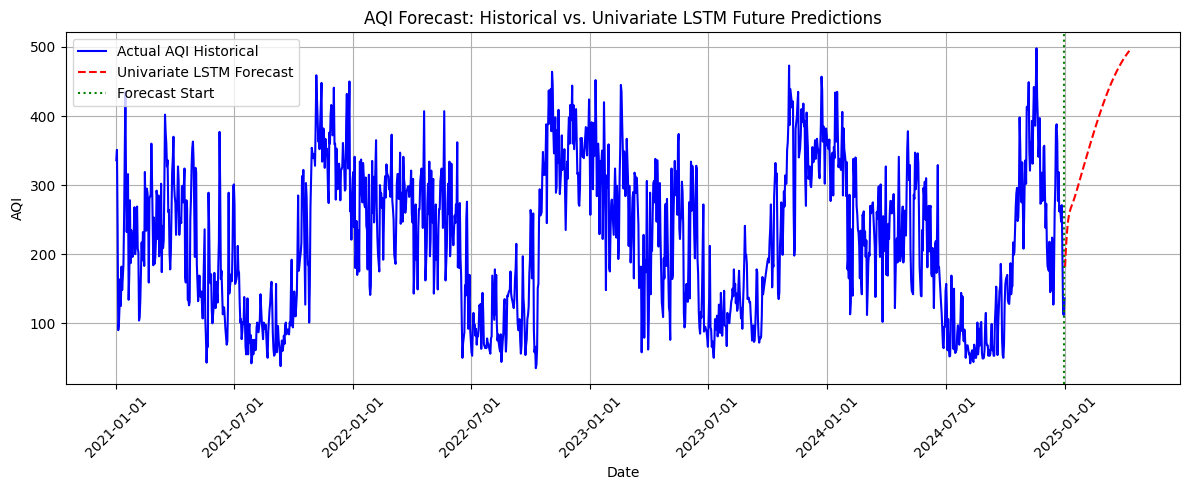

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(12, 5))

if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
    df.set_index('Date', inplace=True)

# Get the last date from the original DataFrame
last_historical_date = df.index.max()

# Create dates for the future predictions
future_dates_uni = pd.date_range(start=last_historical_date + pd.Timedelta(days=1),
                                 periods=n_future_steps, freq='D')

# Plot historical data
plt.plot(df.index, df['AQI'], color='blue', label='Actual AQI Historical')

# Plot the future predictions from the univariate LSTM
plt.plot(future_dates_uni, future_predictions_uni,
         color='red', linestyle='--', label='Univariate LSTM Forecast')

# Mark the start of the forecast
plt.axvline(x=last_historical_date, color='green', linestyle=':', label='Forecast Start')

plt.title('AQI Forecast: Historical vs. Univariate LSTM Future Predictions')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.grid(True)

# Format x-axis dates for better readability
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Download Section

In [ ]:
df.to_csv("aqi_real.csv", index=False)

In [ ]:
df = pd.read_csv('/content/New Delhi AQI.csv')
df
df_compare["date"] = pd.to_datetime(df_compare["date"])
prediction_df = pd.DataFrame({
    "Date": df_compare["date"],
    "AQI": df_compare["actual"],
    "ARIMA_Pred": df_compare["arima_pred"],
    "LSTM_Pred": df_compare["lstm_pred"]
})
prediction_df.to_csv("aqi_prediction.csv", index=False)

In [ ]:
evaluation_df = pd.DataFrame({
    "Model": ["ARIMA", "LSTM"],
    "RMSE": [rmse_arima, rmse_multi],
    "MAE": [mae_arima, mae_multi]
})

evaluation_df.to_csv("model_metrics.csv", index=False)

In [ ]:
df_future_multi = pd.DataFrame({
    "Date": future_dates,
    "LSTM_Forecast": multi_pred_inv.flatten()
})

df_future_multi.to_csv("aqi_forecast.csv", index=False)

In [ ]:
from google.colab import files

# Download all datasets
files.download("aqi_real.csv")
files.download("aqi_prediction.csv")
files.download("model_metrics.csv")
files.download("aqi_forecast.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>